# Set up imports

In [1]:
import logging
import numpy as np
from blastwave import LSSTClient, BOOMCredentialsError
from blastwave.utils import get_source_path, combine_sources
from astropy.time import Time
from tqdm import tqdm

In [2]:
logger = logging.getLogger(__name__)

In [3]:
overwrite = True

# Create LSST Client

In [4]:
client = LSSTClient()

In [5]:
client.get_entry_count()

11647480

In [6]:
client.get_sample_data()

{'_id': 170046106178682956,
 'objectId': '170046106178682956',
 'ssObjectId': None,
 'candidate': {'diaSourceId': 170046106178682956,
  'visit': 2026022200267,
  'detector': 71,
  'diaObjectId': 170046106178682956,
  'parentDiaSourceId': 0,
  'midpointMjdTai': 61094.194368591496,
  'ra': 187.6574683120858,
  'raErr': 1.733970293571474e-06,
  'dec': 7.237033323702315,
  'decErr': 1.6204637631744845e-06,
  'centroid_flag': False,
  'apFlux': -899.5928344726562,
  'apFluxErr': 652.7559814453125,
  'apFlux_flag': False,
  'apFlux_flag_apertureTruncated': False,
  'isNegative': False,
  'snr': 6.463746547698975,
  'psfFlux': -412.87310791015625,
  'psfFluxErr': 342.346923828125,
  'psfChi2': 1831.7554931640625,
  'psfNdata': 1681,
  'psfFlux_flag': False,
  'psfFlux_flag_edge': False,
  'psfFlux_flag_noGoodPixels': False,
  'trailFlux': None,
  'trailFluxErr': None,
  'trailRa': None,
  'trailRaErr': None,
  'trailDec': None,
  'trailDecErr': None,
  'trailLength': None,
  'trailLengthErr':

In [7]:
client.get_sample_data(catalog="LSST_alerts_aux")

{'_id': '313963359359205456',
 'prv_candidates': [{'diaSourceId': 313963359359205456,
   'visit': 2026010800097,
   'detector': 99,
   'diaObjectId': 313963359359205456,
   'parentDiaSourceId': 0,
   'midpointMjdTai': 61049.1170481334,
   'ra': 58.77265609223516,
   'raErr': 4.200323382974602e-05,
   'dec': -49.473616901753424,
   'decErr': 5.349792991182767e-05,
   'centroid_flag': False,
   'apFlux': -859.9091796875,
   'apFluxErr': 278.42181396484375,
   'apFlux_flag': False,
   'apFlux_flag_apertureTruncated': False,
   'isNegative': True,
   'snr': 6.436182022094727,
   'psfFlux': -1280.5611572265625,
   'psfFluxErr': 198.45755004882812,
   'psfChi2': 1748.3990478515625,
   'psfNdata': 1681,
   'psfFlux_flag': False,
   'psfFlux_flag_edge': False,
   'psfFlux_flag_noGoodPixels': False,
   'trailFlux': -1397.1678466796875,
   'trailFluxErr': 4.338618278503418,
   'trailRa': 58.77265102430364,
   'trailRaErr': None,
   'trailDec': -49.47361448091237,
   'trailDecErr': None,
   'trai

# Get latest entry

In [8]:
object_id = "313853517419249797"

In [9]:
s = client.get_source(object_id)

In [10]:
s.get_detections()

,jd,magpsf,sigmapsf,diffmaglim,ra,dec,snr,band,survey,det_type,isdiffpos,estdiffmaglim,mjd
0,2.461025e+06,22.060509,0.069606,23.295776,149.444055,2.548360,15.570031,i,LSST,alert,True,23.293807,61024.245504
1,2.461025e+06,22.013546,0.072831,23.199642,149.444079,2.548405,14.787711,i,LSST,alert,True,23.190873,61024.246003
2,2.461025e+06,21.849556,0.058824,23.267555,149.444058,2.548354,18.107000,i,LSST,alert,True,23.246747,61024.246504
3,2.461025e+06,22.161964,0.081719,23.223045,149.444052,2.548385,13.146742,i,LSST,alert,True,23.211585,61024.247006
4,2.461025e+06,21.940140,0.063398,23.276831,149.444048,2.548363,17.059200,i,LSST,alert,True,23.272611,61024.247509
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,2.461205e+06,20.831993,0.036144,22.778801,149.444082,2.548373,29.698624,u,LSST,alert,True,22.766409,61204.977478
1390,2.461205e+06,20.816601,0.033533,22.844795,149.444081,2.548384,32.135273,u,LSST,alert,True,22.836631,61204.978125
1391,2.461205e+06,21.024240,0.021589,23.530540,149.444093,2.548369,49.785194,g,LSST,alert,True,23.519566,61204.981323
1392,2.461206e+06,20.903870,0.092309,21.832645,149.444043,2.548394,11.689276,r,LSST,alert,True,21.825914,61205.982756


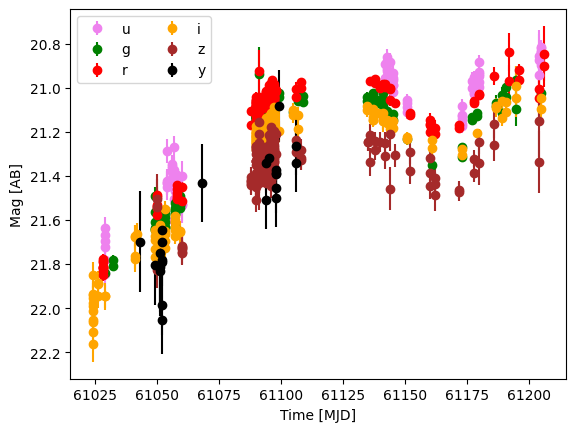

In [11]:
s.show_lightcurve()

# Query by date

In [24]:
datestr = "20260615"

t_now = Time(datestr[:4] + "-" + datestr[4:6] + '-' + datestr[6:] + 'T15:00:00.0',
            format='isot').jd


# rb_cut = {
#     'candidate.reliability': {'$gt': 0.4},
#     'candidate.isDipole': False,
#     'candidate.pixelFlags': False,
#     'candidate.glint_trail': False,
#     'candidate.isNegative': False,
# }
rb_cut = {
    'candidate.reliability': {'$gt': 0.4},
    'candidate.isDipole': {'$eq': False},
    'candidate.pixelFlags': {'$eq': False},
    'candidate.glint_trail': {'$eq': False},
    'candidate.isNegative': {'$eq': False},
    'candidate.centroid_flag': {'$eq': False},
    'candidate.psfFlux_flag': {'$eq': False},
}

new_cuts = {
    "properties.rock": {'$eq': False},
    "properties.star": {'$eq': False},
    'properties.near_brightstar': {'$eq': False},
    "properties.stationary": {'$eq': True},

}

# gt is greater than, lt is lower than
mongodb_filter = {
    'candidate.jd': {
        # '$gt': t_now - 0.2,
        '$gt': t_now - 500.0,
        # '$gt': t_now - 5.0,
        '$lt': t_now
    },
    **rb_cut,
    **new_cuts
}

query = {
    "catalog_name": client.catalog,
    "filter": mongodb_filter,
    "projection": {"objectId": 1},
    "limit": None,
    "max_time_ms": None,
}
query

{'catalog_name': 'LSST_alerts',
 'filter': {'candidate.jd': {'$gt': np.float64(2460707.125),
   '$lt': np.float64(2461207.125)},
  'candidate.reliability': {'$gt': 0.4},
  'candidate.extendedness': {'$lt': 0.7},
  'candidate.isDipole': {'$eq': False},
  'candidate.pixelFlags': {'$eq': False},
  'candidate.glint_trail': {'$eq': False},
  'candidate.isNegative': {'$eq': False},
  'candidate.centroid_flag': {'$eq': False},
  'candidate.psfFlux_flag': {'$eq': False},
  'properties.rock': {'$eq': False},
  'properties.star': {'$eq': False},
  'properties.near_brightstar': {'$eq': False},
  'properties.stationary': {'$eq': True}},
 'projection': {'objectId': 1},
 'limit': None,
 'max_time_ms': None}

In [25]:
client.count(query)

340073

In [26]:
res = client.query(query)

In [27]:
res[0]

{'_id': 313637921221509148, 'objectId': '313629129584934927'}

In [28]:
object_ids = [x["objectId"] for x in res]
len(object_ids)

340073

In [29]:
object_ids = list(set(object_ids))
len(object_ids)

13793

In [18]:
object_ids

['313835835875131440',
 '313871014887424021',
 '313871013655871513',
 '313963359528026360',
 '313875416412586004',
 '313765480729411617',
 '313963356834234407',
 '170032891008385160',
 '313756649407381512',
 '313875415157964969',
 '170032880060203058',
 '313765480710537249',
 '313998534773833740',
 '170028522343497805',
 '313875415059923015',
 '170028500590788677',
 '170028487417528937',
 '313756673077411902',
 '170433141221621863',
 '313677517357580328',
 '313967766144024643',
 '313871013956812811',
 '313871013442486398',
 '170028486997049413',
 '170028527255027807',
 '313871014242025523',
 '313893021503979573',
 '313875416797937760',
 '313923786240950311',
 '313853533516988449',
 '170028526449197109',
 '313985347862659123',
 '313985348339761333',
 '314003015877525524',
 '313862212455760015',
 '313765480597291109',
 '170028526620115001',
 '170028526374748217',
 '170032926323376394',
 '313954555391901770',
 '313862204829466699',
 '170028538572832858',
 '313893022944722998',
 '170032883

# Save sources

In [19]:
skipped = []

for name in tqdm(object_ids):
    path = get_source_path(name)
    
    # Skip existing sources
    if path.exists() & (not overwrite):
        continue

    # try:
    s = client.get_source(name)
    if s.ndethist < 2:
        skipped.append(name)
        continue
    
    s.to_parquet()

100%|██████████████████████████████████| 24240/24240 [2:17:18<00:00,  2.94it/s]


In [20]:
print(f"{len(skipped)} sources had fewer than 2 good detections ({100. * float(len(skipped))/len(object_ids):.0f}% of total)")

13597 has fewer than 2 good detections (56 %)


In [21]:
combine_sources()